In [1]:
#import sys
# Add your lenscarf site-packages to the path
#sys.path.append('/users/odarwish/lenscarf/lib/python3.12/site-packages')
#sys.path.append('/users/odarwish/abacusutils/')

import numpy as np

import matplotlib.pyplot as plt

from abacusnbody.data.read_abacus import read_asdf

import numpy as np

from abacusnbody.analysis.tsc import tsc_parallel

import matplotlib.pyplot as plt

from abacusnbody.analysis.power_spectrum import calc_power, calc_pk_from_deltak, get_k_mu_edges
from abacusnbody.analysis import power_spectrum as ps

from scipy.fft import rfftn, irfftn

import astropy

from classy import Class

import yaml

from abacusnbody.analysis.power_spectrum import calc_power
from abacusnbody.data import read_abacus
from pathlib import Path

## Specify useful info

In [2]:
scratch = "/capstor/scratch/cscs/odarwish/ABACUS/"

z = 0.5 #redshift of the simulation

box = 2000 #box size, in Gpc/h
nthread = 128 #number of threads to use for FFT calcs
ngrid = 576#*2, grid size on which to paste quantities

paste = 'TSC' #Triangular Shaped Cloud mass assignment scheme
interlaced = True #reduces aliasing artifacts in the power spectrum
compensated = True #applies mass assignment compensation (basically a deconvolution)

logk = False
k_hMpc_max = np.pi * ngrid / box + 1.0e-6
nbins_k = ngrid // 2
dtype = np.float32

In [3]:
#this configuration file has everything needed to get theory curves, as well as some information about the simulation
configuration = '../configs/abacus/config_abacus_recs_high_n.yaml'

with open(configuration, 'r') as f:
    config = yaml.safe_load(f)

ps_main_directory = config['power_spectrum']['main_directory']
name_config = config['name']
gen_nl_power = np.loadtxt(ps_main_directory+name_config+"/"+config['power_spectrum']['nonlinear'])
gen_power = np.loadtxt(ps_main_directory+name_config+"/"+config['power_spectrum']['linear'])


output_config = config['output']
filename_prefix = output_config['filename_prefix']
filename_prefix = output_config['filename_prefix']
output_dir = Path(output_config['directory'])/config['name']

In [4]:
#let's get some quantities from the abacus utils
from abacusnbody.metadata import get_meta
from abacusnbody.hod.zcv.ic_fields import load_dens, load_disp

sim_name = f"{config['sim_params']['sim_name_base']}{0:03}"
z = config['sim_params']['z_mock']

meta = get_meta(sim_name, redshift=z)

z_ic = meta['InitialRedshift']

Dz = meta['GrowthTable']
ztarget = 0.5
zpk = meta['ZD_Pk_file_redshift']  # 1.0
pk = meta['CLASS_power_spectrum']
linear_k  = pk['k (h/Mpc)']
input_pk = pk['P (Mpc/h)^3']
linear_pk = input_pk * (Dz[ztarget] / Dz[zpk])**2

D_ratio = meta['GrowthTable'][meta['Redshift']] / meta['GrowthTable'][z_ic] #re-scaling growth factor between initial redshift and current redshift

#here we specify the inital conditions, useful to get the linear density field
ic_dir = "/users/odarwish/scratch/ABACUS/ic/"
ic = load_dens(ic_dir, sim_name, ngrid)
ic_fft = rfftn(ic, overwrite_x=False, workers=nthread)
ic_fft /= ic.size


from jax import numpy as jnp
from qeep import rec, rec_utils as ru, qeutils as qu

pnlinf = lambda kmag: jnp.interp(kmag, gen_nl_power[:,0], gen_nl_power[:,1])
plinf = lambda kmag: jnp.interp(kmag, gen_power[:,0], gen_power[:,1])
kmin, kmax = config['k_range']['kmin'], config['k_range']['kmax'] #kmin, kmax of reconstruction


kr_config = config['k_range']
kmin = kr_config['kmin']
kmax = kr_config['kmax']
k_samples = kr_config['k_samples']
k_min_analysis = kr_config['k_min_analysis']
k_max_analysis = kr_config['k_max_analysis']

kmin_max = 2*k_min_analysis
Ks_ = np.linspace(k_min_analysis, kmin_max, 20)
Ks = np.logspace(np.log10(kmin_max), np.log10(k_max_analysis), k_samples)
Ks = np.concatenate([Ks_, Ks])
Ks = np.unique(Ks)

W = ps.get_W_compensated(box, ngrid, paste, interlaced)

f = (
    W[:, np.newaxis, np.newaxis]
    * W[np.newaxis, :, np.newaxis]
    * W[np.newaxis, np.newaxis, : (ngrid // 2 + 1)]
    )


## First, let's just check normalization with linear density

(1e-07, 1)

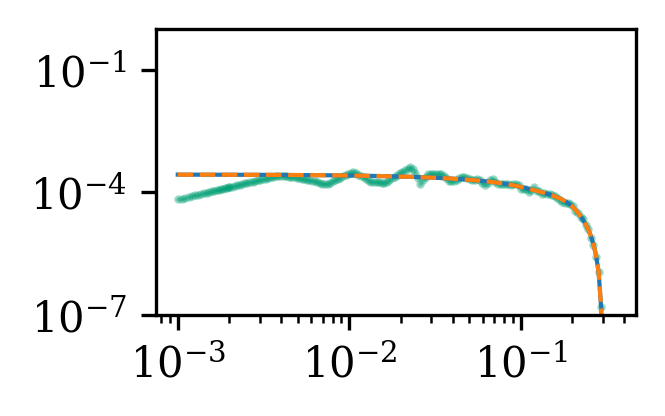

In [5]:
# let's get some quantities from the abacus utils
from abacusnbody.metadata import get_meta
from abacusnbody.hod.zcv.ic_fields import load_dens, load_disp

simindex = 0
sim_name = f"{config['sim_params']['sim_name_base']}{simindex:03}"
z = config['sim_params']['z_mock']

meta = get_meta(sim_name, redshift=z)

z_ic = meta['InitialRedshift']

Dz = meta['GrowthTable']
ztarget = 0.5
zpk = meta['ZD_Pk_file_redshift']  # 1.0
pk = meta['CLASS_power_spectrum']
linear_k  = pk['k (h/Mpc)']
input_pk = pk['P (Mpc/h)^3']
linear_pk = input_pk * (Dz[ztarget] / Dz[zpk])**2

D_ratio = meta['GrowthTable'][meta['Redshift']] / meta['GrowthTable'][z_ic] #re-scaling growth factor between initial redshift and current redshift

#here we specify the inital conditions, useful to get the linear density field
ic_dir = "/users/odarwish/scratch/ABACUS/ic/"
ic = load_dens(ic_dir, sim_name, ngrid)*D_ratio
ic_fft = rfftn(ic, overwrite_x=False, workers=nthread)
ic_fft /= ic.size


from jax import numpy as jnp
from qeep import rec, rec_utils as ru, qeutils as qu

pnlinf = lambda kmag: jnp.interp(kmag, gen_nl_power[:,0], gen_nl_power[:,1])
plinf = lambda kmag: jnp.interp(kmag, gen_power[:,0], gen_power[:,1])
kmin, kmax = config['k_range']['kmin'], config['k_range']['kmax'] #kmin, kmax of reconstruction


#here we are loading some simulation results
#we used the ZCV utils from abacusutils to get this info
z_mock = 0.5
scratch = f"/users/odarwish/scratch/ABACUS/abacus_out/{sim_name}/z{z_mock:.3f}/galaxies/"

key = "g"

kr_config = config['k_range']
kmin = kr_config['kmin']
kmax = kr_config['kmax']
k_samples = kr_config['k_samples']
k_min_analysis = kr_config['k_min_analysis']
k_max_analysis = kr_config['k_max_analysis']

kmin_max = 2*k_min_analysis
Ks_ = np.linspace(k_min_analysis, kmin_max, 20)
Ks = np.logspace(np.log10(kmin_max), np.log10(k_max_analysis), k_samples)
Ks = np.concatenate([Ks_, Ks])
Ks = np.unique(Ks)

W = ps.get_W_compensated(box, ngrid, paste, interlaced)

f = (
    W[:, np.newaxis, np.newaxis]
    * W[np.newaxis, :, np.newaxis]
    * W[np.newaxis, np.newaxis, : (ngrid // 2 + 1)]
    )

scratch = f"/users/odarwish/scratch/ABACUS/abacus_out/AbacusSummit_base_c000_ph{simindex:03}/z0.500/galaxies/"

pnlinf = lambda kmag: jnp.interp(kmag, gen_nl_power[:,0], gen_nl_power[:,1])
plinf = lambda kmag: jnp.interp(kmag, gen_power[:,0], gen_power[:,1])

N = ic.shape[0]
kgrid, kmag = ru.get_kgrid_kmag(box, N)
PNL, PL = pnlinf(kmag), plinf(kmag)
factor_conv = np.sqrt(PNL/PL)
factor_conv[PL == 0] = 0.

ic_rescal = irfftn(ic_fft/f, overwrite_x=False, workers=nthread)
ic_shift_AB_rescal = rec.get_rec(key, ic_rescal, box, kmin, kmax, pnlinf, plinf, real_field_2 = ic_rescal, Ptot_interp_2 = pnlinf)

if key != "t":
    ic_shift_AB = rec.get_rec(key, ic, box, kmin, kmax, pnlinf, plinf, real_field_2 = ic, Ptot_interp_2 = pnlinf)
else:
    PNL = np.array(PNL)
    PL = np.array(PL)
    ic_shift_AB = rec.get_rec("t", ic, box, kmin, kmax, PNL, PL)


#d = irfftn(ic_fft*factor_conv, overwrite_x=True, workers=nthread)
#ic_shift_AB = rec.get_rec(key, d, box, kmin, kmax, pnlinf, plinf, real_field_2 = d, Ptot_interp_2 = pnlinf)
#ic_shift_AB = rec.get_shift_n_rec_old(ic, box, kmin, kmax, pnlinf, plinf)#, real_field_2 = d, Ptot_interp_2 = pnlinf)

#ic_shift_AB = rec.get_growth_rec_original(ic, box, kmin, kmax, pnlinf(kmag), plinf(kmag))


k, p = ru.calc_power_mu0_x_axis(ic_shift_AB.astype(complex), box, delta_k2 = ic_fft/ic.size)
p = np.interp(Ks, k, p)

k, pauto = ru.calc_power_mu0_x_axis(ic_shift_AB.astype(complex), box)
pauto = np.interp(Ks, k, pauto)

k, pauto_rescale = ru.calc_power_mu0_x_axis(ic_shift_AB_rescal.astype(complex), box)
pauto_rescale = np.interp(Ks, k, pauto_rescale)

path = "/users/odarwish/qeep/results/abacus_delta_m/"
norm = np.load(path+f"analysis_delta_m_theory_normalization_AB.npy", allow_pickle = True).item()
var = np.load(path+f"analysis_delta_m_theory_variance_AB.npy", allow_pickle = True).item()

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.ticker import LogLocator, LogFormatter, AutoMinorLocator
from matplotlib.gridspec import GridSpec
from matplotlib import patheffects
import matplotlib as mpl


plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "Times New Roman", "DejaVu Serif"],
    "mathtext.fontset": "cm"  # Use Computer Modern math font
})


COLORBLIND_PALETTE = [
    '#0072B2',  # Blue
    '#D55E00',  # Orange
    '#009E73',  # Green
    '#CC79A7',  # Pink
    '#56B4E9',  # Light blue
    '#E69F00',  # Yellow
    '#000000',  # Black
    '#F0E442'   # Light yellow
]

# Use golden ratio for figure dimensions
GOLDEN_RATIO = (5**0.5 - 1) / 2
FIG_WIDTH = 2  # inches
FIG_HEIGHT = 2 * GOLDEN_RATIO
DPI = 300


fig = plt.figure(figsize=(FIG_WIDTH, FIG_HEIGHT), dpi=DPI, facecolor='white')
# Use GridSpec for more control over plot layout
gs = GridSpec(1, 1, figure=fig, left=0.15, right=0.95, bottom=0.15, top=0.92)
ax = fig.add_subplot(gs[0, 0])

size = ic.size
factor = 1

N = norm[(key, key)]**-1.
N = np.nan_to_num(N)

V = var[(key, key)]

ax.scatter(Ks, pauto*factor**4, color = COLORBLIND_PALETTE[2], alpha = 0.4, s = 1)
ax.loglog(Ks, N**-1, lw = 1)
ax.loglog(Ks, V, lw = 1, ls = "--")
ax.set_ylim(1e-7, 1)

In [9]:
from nbodykit.source.mesh.field import FieldMesh
import nbodykit.lab as nblab
from pmesh.pm import RealField, ComplexField

class Smoother(object):
    """
    Class to apply smoothing to field.
    """
    def __init__(self):
        raise NotImplementedError

    def get_smoothing_kernel_of_Nth_iteration(self, N):
        raise NotImplementedError


class HardSmoother(Smoother):
    """
    Apply Gaussian smoothing to field.
    """
    def __init__(
        self,
        kmin, kmax,
        name='HardSmoother'
        ):
        self.kmin = kmin
        self.kmax = kmax
        self.name = name

    def get_smoothing_kernel(self):
        kmin, kmax = self.kmin, self.kmax
        if kmin is None or kmax==0.:
            def kernel_fcn(k3vec, val):
                return val
        else:
            def kernel_fcn(k3vec, val):
                k2 = sum(ki**2 for ki in k3vec)  # |\vk|^2 on the mesh
                kmag = np.sqrt(k2)
                window = (kmag >= kmin) & (kmag <= kmax)
                return  window * val
        return kernel_fcn

    def apply_smoothing(self, meshsource):
        # make a copy
        out = FieldMesh(meshsource.compute(mode='complex'))
        kernel_fcn = self.get_smoothing_kernel()
        out = out.apply(kernel_fcn, kind='wavenumber', mode='complex')
        return out

    def to_dict(self):
        return dict(
            kmin=self.kmin, kmax = self.kmax, name=self.name)

    def __str__(self):
        return json.dumps(self.to_dict())

    def __repr__(self):
        return self.__str__()

In [10]:
def ivf_operator(k3vec, val):
    k2 = sum(ki**2 for ki in k3vec)  # |\vk|^2 on the mesh
    kmag = np.sqrt(k2)
    pnlinear_interp = pnlinf(kmag)
    return 1/pnlinear_interp*val

def growth_estimator(k3vec, val):
    Fg = 17/21
    k2 = np.sum(ki**2 for ki in k3vec)  # |\vk|^2 on the mesh
    kmag = np.sqrt(k2)
    plinear_interp = plinf(kmag)
    return 4*Fg*plinear_interp*val/2



def get_estimator(input_field):
    kmin, kmax = 0.051, 0.15
    smoother = HardSmoother(kmin, kmax)
    delta_mesh = nblab.ArrayMesh(input_field, BoxSize=box)
    delta_mesh_smoothed = smoother.apply_smoothing(delta_mesh)
    out = FieldMesh(delta_mesh_smoothed.compute(mode='complex'))
    delta_ivf = out.apply(ivf_operator, kind='wavenumber', mode='complex')
    
    out = FieldMesh(delta_ivf.compute(mode='complex'))
    delta_wf = out.apply(growth_estimator, kind='wavenumber', mode='complex')
    
    delta_ivf_real = delta_ivf.compute(mode="real")
    delta_wf_real = delta_wf.compute(mode="real")

    growth_nbody = delta_ivf_real*delta_wf_real

    return growth_nbody

In [11]:
growth_ic = get_estimator(ic)

/tmp/ipykernel_147988/470424799.py:9: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  k2 = np.sum(ki**2 for ki in k3vec)  # |\vk|^2 on the mesh


In [12]:
boxsize = box
k_bin_width = 1.0
dk = 2.0 * np.pi / boxsize * k_bin_width
kmin = 2.0 * np.pi / boxsize / 2.0

from nbodykit.algorithms.fftpower import FFTPower

r = FFTPower(growth_ic, mode='1d')
Pk = r.power

# Extract k and P(k)
kn = Pk['k']
powergn = Pk['power'].real
modesn = Pk['modes']

In [13]:
ic_shift_AB_real = irfftn(ic_shift_AB)
delta_mesh = nblab.ArrayMesh(ic_shift_AB_real, BoxSize=box)
r = FFTPower(delta_mesh, mode='1d')
Pk = r.power
kn = Pk['k']
powergn_alt = Pk['power'].real

In [14]:
def quick_nbody_power(input_field_fft, second_fft = None):
    delta_mesh = nblab.ArrayMesh(irfftn(input_field_fft), BoxSize=box)
    second = nblab.ArrayMesh(irfftn(second_fft), BoxSize=box) if second_fft is not None else None
    r = FFTPower(delta_mesh, mode='1d', second = second)
    Pk = r.power
    kn = Pk['k']
    powergn_alt = Pk['power'].real
    kn = Pk['k']
    powergn_alt = Pk['power'].real
    return kn, powergn_alt*size**2

(1e-07, 1)

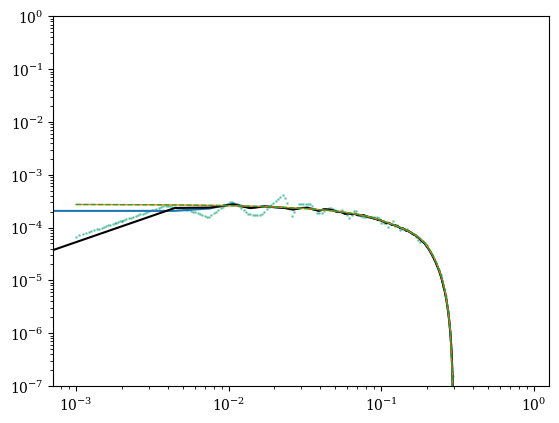

In [15]:
plt.scatter(Ks, pauto*factor**4, color = COLORBLIND_PALETTE[2], alpha = 0.4, s = 1)
plt.plot(kn, powergn)

plt.plot(kn, powergn_alt*size**2, color = "black")

plt.loglog(Ks, N**-1, lw = 1)
plt.loglog(Ks, V, lw = 1, ls = "--")
plt.ylim(1e-7, 1)

/tmp/ipykernel_147988/4151953920.py:13: RuntimeWarning: overflow encountered in square
  plt.scatter(Ks, N**2*pauto*factor**2, color = COLORBLIND_PALETTE[2], alpha = 0.4, s = 1)
/tmp/ipykernel_147988/4151953920.py:17: RuntimeWarning: overflow encountered in square
  plt.plot(Ks, np.interp(Ks, kn, powergn)*N**2)


(100, 1000000.0)

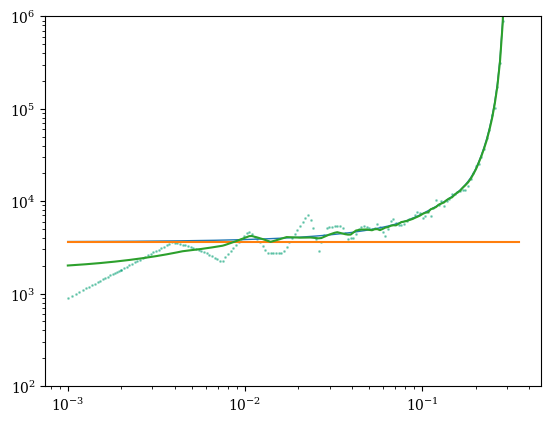

In [16]:
#compare with squeezed growth 

kk = np.linspace(0.051, 0.15, 1000)
num = plinf(kk)
den = pnlinf(kk)
y = (num/den)**2*kk**2
y *= 4*np.pi/(2*np.pi)**3*8*(17/21)**2
squeezed = np.trapz(y, kk)

size = ic.size
factor = 1

plt.scatter(Ks, N**2*pauto*factor**2, color = COLORBLIND_PALETTE[2], alpha = 0.4, s = 1)
plt.loglog(Ks, N, lw = 1)
plt.plot(Ks, squeezed**-1.+Ks*0.)

plt.plot(Ks, np.interp(Ks, kn, powergn)*N**2)
#plt.loglog(Ks, V, lw = 1, ls = "--")
plt.ylim(100, 1e6)

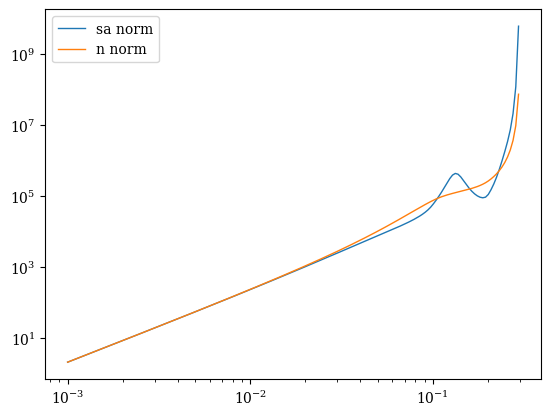

In [17]:
key = "sa"
N = norm[(key, key)]**-1.
plt.loglog(Ks, N, lw = 1, label = "sa norm")

key = "n"
N = norm[(key, key)]**-1.
plt.loglog(Ks, N, lw = 1, label = "n norm")

plt.legend()

(0.006, 0.2)

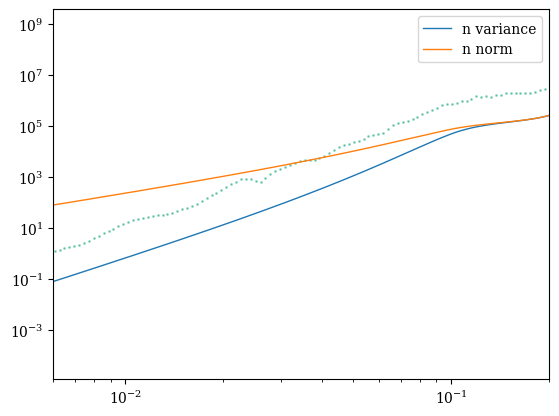

In [20]:
#plt.scatter(k, pauto2*factor**4*4, color = "black", alpha = 0.4, s = 1)
#plt.scatter(k, pauto3*factor**4*4, color = "yellow", alpha = 0.4)
#plt.scatter(k, pauto_rescaled*4, color = "red", alpha = 0.4, s = 1)

keys = ["n"]

for k_key in keys:
    V = var[(k_key, k_key)]
    N = norm[(k_key, k_key)]**-1.
    plt.loglog(Ks, V*N**2, lw = 1, label = f"{k_key} variance")
    plt.loglog(Ks, N, lw = 1, label = f"{k_key} norm")

#N2 = norm2[(key, key)]**-1./4
#plt.loglog(Ks2, np.interp(Ks2, Ks, V)*N2**2, lw = 1, ls = "--")


plt.scatter(Ks, N**2*pauto*factor**4, color = COLORBLIND_PALETTE[2], alpha = 0.4, s = 1)

plt.legend()
#plt.ylim(1e-2, 1e6)
plt.xlim(6e-3, 2e-1)

In [63]:
samples = ["LRG", "ELG"]
key = "n"
trA, trB = samples

#path = "/users/odarwish/qeep/results/abacus_recs/"
#simindex = 0
#norm3 = np.load(path+f"analysis_AbacusSummit_base_c000_ph{simindex:03}_z0.500_{trA}_{trB}_normalization_AB.npy", allow_pickle = True).item()
#var3 = np.load(path+f"analysis_AbacusSummit_base_c000_ph{simindex:03}_z0.500_{trA}_{trB}_variance_AB.npy", allow_pickle = True).item()

/tmp/ipykernel_104056/3948530324.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


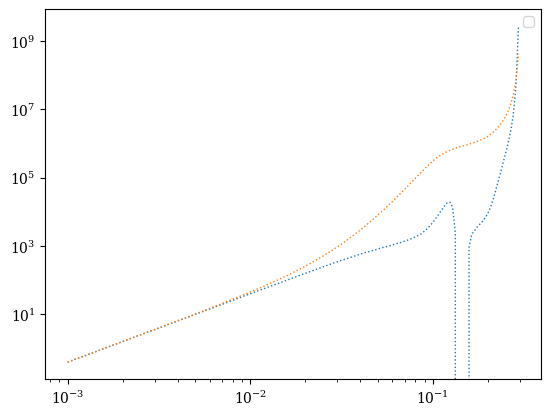

In [64]:

keys = ["n"]#, "s"]#, "n"]

for k_key in keys:
    V = var[(k_key, k_key)]
    N = norm[(k_key, k_key)]**-1.
    #p = plt.loglog(Ks, V*N**2, lw = 1, label = f"{k_key} variance")
    #plt.loglog(Ks, N, lw = 1, ls = "--", label = f"{k_key} norm")


    V = var3[(k_key, k_key)]
    N = norm3[(k_key, k_key)]**-1.
    plt.loglog(Ks, V*N**2, lw = 1, ls = ":")#, color = p[0].get_color(), ls = ":")
    #plt.loglog(Ks, N, lw = 1, ls = "--", label = f"{k_key} norm")
plt.legend()

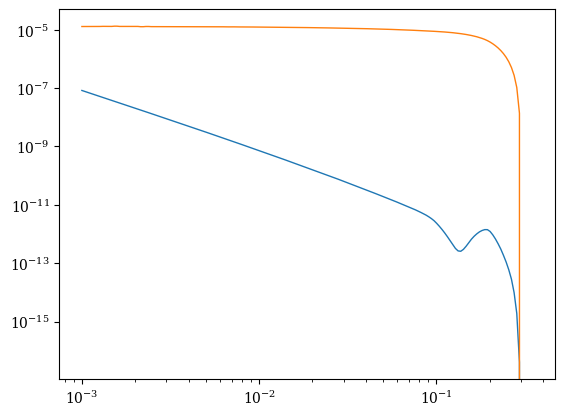

In [65]:
key = "sa"
V = var[(key, key)]
plt.loglog(Ks, V, lw = 1)
N = norm[(key, key)]
#plt.loglog(Ks, N, lw = 1, ls = "--")

key = "n"
V = var[(key, key)]
plt.loglog(Ks, V, lw = 1)
N = norm[(key, key)]
#plt.loglog(Ks, N, lw = 1, ls = "--")

## Apply to non-linear matter

In [66]:
simindex = 0
sim_name = f"{config['sim_params']['sim_name_base']}{simindex:03}"

direc = "/capstor/scratch/cscs/odarwish/ABACUS/"
delta_m = np.load(direc+f"delta_matter_{simindex}.npy")

In [67]:
ic_dir = "/users/odarwish/scratch/ABACUS/ic/"
ic = load_dens(ic_dir, sim_name, ngrid)*D_ratio
ic_fft = rfftn(ic, overwrite_x=False, workers=nthread)
ic_fft /= ic.size

delta_m_fft = rfftn(delta_m, overwrite_x=False, workers=nthread)
delta_m_fft /= delta_m.size

In [68]:
k, matter_auto = ru.calc_power_mu0_x_axis(delta_m_fft/f, box)
k, matter_cross = ru.calc_power_mu0_x_axis(delta_m_fft.astype(np.complex128)/f, box, delta_k2 = ic_fft.astype(np.complex128)/f)

In [70]:
#plt.loglog(k, matter_auto)
#plt.loglog(k, matter_cross)
#plt.plot(gen_nl_power[:,0], gen_nl_power[:,1])
#plt.plot(gen_power[:,0], gen_power[:,1])
#plt.ylim(100)

In [ ]:

if key != "t":
    ic_shift_AB = rec.get_rec(key, ic, box, kmin, kmax, pnlinf, plinf, real_field_2 = ic, Ptot_interp_2 = pnlinf)
else:
    PNL = np.array(PNL)
    PL = np.array(PL)
    ic_shift_AB = rec.get_rec("t", ic, box, kmin, kmax, PNL, PL)

In [81]:
key = "g"
Nsize = ic.size
#ic_shift_AB = rec.get_rec(key, delta_m, box, kmin, kmax, pnlinf, plinf, real_field_2 = delta_m, Ptot_interp_2 = pnlinf)/Nsize**2
matter_rec = rec.get_rec(key, delta_m, box, kmin, kmax, pnlinf, plinf)#/Nsize**2

ic_rec = rec.get_rec(key, ic, box, kmin, kmax, pnlinf, plinf)#/Nsize**2

k, rec_cross = ru.calc_power_mu0_x_axis(matter_rec.astype(np.complex128), box, delta_k2 = ic_fft.astype(np.complex128)/f)
rec_cross = np.interp(Ks, k, rec_cross)

k, rec_auto = ru.calc_power_mu0_x_axis(matter_rec.astype(np.complex128), box)
rec_auto = np.interp(Ks, k, rec_auto)

k, rec_ic_auto = ru.calc_power_mu0_x_axis(ic_rec.astype(np.complex128), box)
rec_ic_auto = np.interp(Ks, k, rec_ic_auto)

path = "/users/odarwish/qeep/results/abacus_delta_m/"
norm = np.load(path+f"analysis_delta_m_theory_normalization_AB.npy", allow_pickle = True).item()
var = np.load(path+f"analysis_delta_m_theory_variance_AB.npy", allow_pickle = True).item()

normalization = np.array(norm[(key, key)]**-1.)
bias = 0
kinds = ["s", "t", "g"]
for kk in kinds:
    bias += (normalization*norm[(key, kk)])

Plinear = np.interp(Ks, gen_power[:,0], gen_power[:,1])

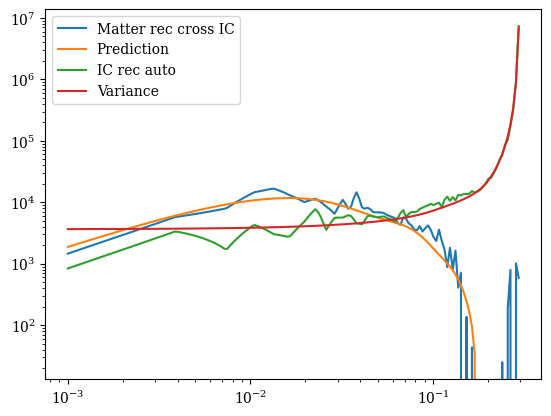

In [82]:
plt.loglog(Ks, rec_cross*normalization, label = "Matter rec cross IC")
plt.plot(Ks, Plinear*bias, label = "Prediction")

plt.loglog(Ks, rec_ic_auto*normalization**2, label = "IC rec auto")
plt.loglog(Ks, normalization**2*var[(key, key)], label = "Variance")

plt.legend()

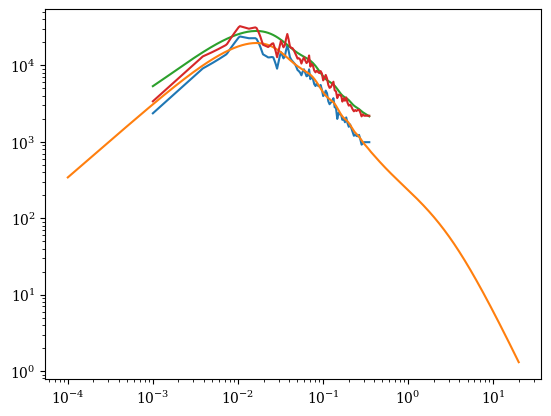

In [83]:
scratch = f"/users/odarwish/scratch/ABACUS/abacus_out/AbacusSummit_base_c000_ph{simindex:03}/z0.500/galaxies/"
delta_LRG = np.load(scratch+f"LRG_delta_g.npy")
delta_LRG_fft = rfftn(delta_LRG, overwrite_x=False, workers=nthread)
delta_LRG_fft /= delta_LRG.size

out_info_A = np.load(scratch+f"LRG_out_info.npy", allow_pickle=True).item()

kA = out_info_A["k"]
PAA = out_info_A["Ptot"]
pnlinf_A = lambda kmag: jnp.interp(kmag, kA, PAA)

k, cross_lrg = ru.calc_power_mu0_x_axis(delta_m_fft.astype(np.complex128)/f, box, delta_k2 = delta_LRG_fft.astype(np.complex128)/f)
cross_lrg = np.interp(Ks, k, cross_lrg)

k, auto_lrg = ru.calc_power_mu0_x_axis(delta_LRG_fft.astype(np.complex128)/f, box)
auto_lrg = np.interp(Ks, k, auto_lrg)

matter_auto_interp = np.interp(Ks, k, matter_auto)

plt.loglog(Ks, cross_lrg)
plt.plot(gen_nl_power[:,0], gen_nl_power[:,1]*out_info_A["b1"])

plt.plot(Ks, pnlinf_A(Ks))
plt.loglog(Ks, auto_lrg)

In [104]:
measurements = {}
for key in ["s", "g"]:

    results_temp = {}
    
    delta_g_matter_rec = rec.get_rec(key, delta_LRG, box, kmin, kmax, pnlinf_A, plinf, real_field_2 = delta_m, Ptot_interp_2 = pnlinf)
    #delta_g_matter_rec_swap = rec.get_rec(key, delta_m, box, kmin, kmax, pnlinf, plinf, real_field_2 = delta_LRG, Ptot_interp_2 = pnlinf_A)
    
    k, rec_cross = ru.calc_power_mu0_x_axis(delta_g_matter_rec.astype(np.complex128), box, delta_k2 = ic_fft.astype(np.complex128)/f)
    rec_cross = np.interp(Ks, k, rec_cross)

    k, rec_auto = ru.calc_power_mu0_x_axis(delta_g_matter_rec.astype(np.complex128), box)
    rec_auto = np.interp(Ks, k, rec_auto)
    
    #k, rec_swap_cross = ru.calc_power_mu0_x_axis(delta_g_matter_rec_swap.astype(np.complex128), box, delta_k2 = ic_fft.astype(np.complex128)/f)
    #rec_swap_cross = np.interp(Ks, k, rec_swap_cross)

    results_temp["cross"] = rec_cross
    results_temp["auto"] = rec_auto
    #results_temp["auto"] = rec_cross
    measurements[key] = results_temp

#plt.loglog(Ks, rec_cross)
#plt.loglog(Ks, rec_swap_cross)

In [98]:
kk_arr, pp_arr = quick_nbody_power(delta_g_matter_rec, second_fft = ic_fft)

In [107]:
kk_arr, pp_auto_arr = quick_nbody_power(delta_g_matter_rec)

/tmp/ipykernel_104056/3313471331.py:31: RuntimeWarning: invalid value encountered in multiply
  variance = np.array(out_variance_AB[(key, key)])*normalization**2
/tmp/ipykernel_104056/3313471331.py:42: RuntimeWarning: invalid value encountered in multiply
  shot_bis *= normalization*0


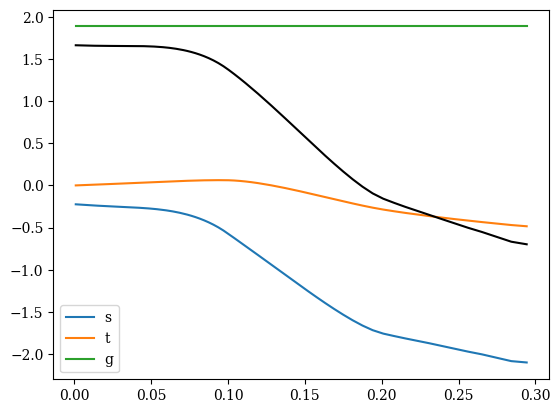

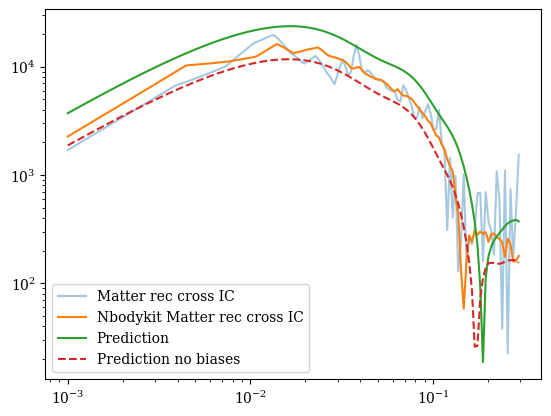

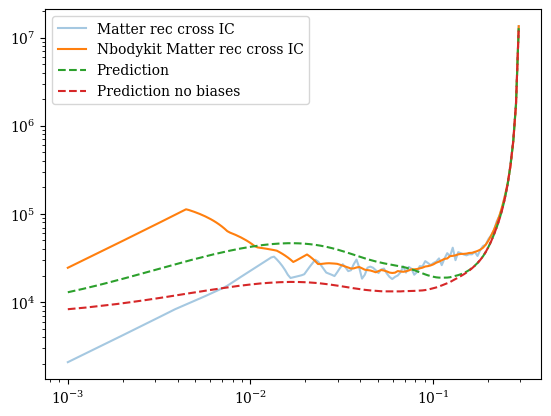

In [110]:
g = lambda b1_A, b2_A, b1_B, b2_B: b1_A*b1_B+1/2*21/17*(b1_A*b2_B+b1_B*b2_A) 
s = lambda b1_A, b1_B: b1_A*b1_B
t = lambda b1_A, bs2_A, b1_B, bs2_B:  b1_A*b1_B+1/2*7/2*(b1_A*bs2_B+b1_B*bs2_A) 

b2_A = out_info_A["b2_L"]/2+4/21*(out_info_A["b1"]-1)
#b2_A = out_info_A["b2"]

biases_rec = {"g": g(out_info_A["b1"], b2_A, 1., 0), "s": s(out_info_A["b1"], 1), "t": t(out_info_A["b1"], out_info_A["bs"], 1., 0.)}

#biases_rec = {"g": g(out_info_A["b1"], b2_A, out_info_A["b1"], b2_A), "s": s(out_info_A["b1"], out_info_A["b1"]), "t": t(out_info_A["b1"], out_info_A["bs"], out_info_A["b1"], out_info_A["bs"])}

key = "g"
rec_cross = measurements[key]["cross"]*(1/Nsize**2 if key != "g" else 1.)
rec_auto  = measurements[key]["auto"]*(1/Nsize**4 if key != "g" else 1.)

path = "/users/odarwish/qeep/results/abacus_recs_matter/"
samples = ["LRG", "matter"]

#path = "/users/odarwish/qeep/results/abacus_recs/"
#samples = ["LRG", "LRG"]

filename_prefix = output_config['filename_prefix']+f"_{sim_name}_z{z_mock:.3f}_{samples[0]}_{samples[1]}"
out_normalization_AB = np.load(path + f"{filename_prefix}_normalization_AB.npy", allow_pickle=True).item()
out_variance_AB = np.load(path + f"{filename_prefix}_variance_AB.npy", allow_pickle = True).item()
bis = np.load(path+f"analysis_AbacusSummit_base_c000_ph{simindex:03}_z0.500_{samples[0]}_{samples[1]}_shot_bispectrum_AB.npy", allow_pickle = True).item()
tris = np.load(path+f"analysis_AbacusSummit_base_c000_ph{simindex:03}_z0.500_{samples[0]}_{samples[1]}_shot_trispectrum_AB.npy", allow_pickle = True).item()
shot_bis = bis[(key, key)]
shot_tris = tris[(key, key)]

normalization = np.array(out_normalization_AB[(key, key)]**-1.)
variance = np.array(out_variance_AB[(key, key)])*normalization**2

bias = 0
unbiased_bias = 0
kinds = ["s", "t", "g"]
for kk in kinds:
    temp = (normalization*out_normalization_AB[(key, kk)])*biases_rec[kk]
    bias += temp
    unbiased_bias += (normalization*out_normalization_AB[(key, kk)])
    plt.plot(Ks, temp, label = kk)

shot_bis *= normalization*0
shot_tris *= normalization**2

plt.plot(Ks, bias, color = "black")
plt.legend()
plt.show()    
Plinear = np.interp(Ks, gen_power[:,0], gen_power[:,1])

plt.loglog(Ks, abs(rec_cross*normalization), label = "Matter rec cross IC", alpha = 0.4)
plt.loglog(Ks, abs(np.interp(Ks, kk_arr, pp_arr)*normalization), label = "Nbodykit Matter rec cross IC")
plt.plot(Ks, abs(Plinear*bias+shot_bis), label = "Prediction")
plt.plot(Ks, abs(Plinear*unbiased_bias), label = "Prediction no biases", ls = "--")

plt.legend()
plt.show()

plt.loglog(Ks, abs(rec_auto*normalization**2), label = "Matter rec cross IC", alpha = 0.4)
plt.loglog(Ks, abs(np.interp(Ks, kk_arr, pp_auto_arr)*normalization**2), label = "Nbodykit Matter rec cross IC")
plt.plot(Ks, abs(Plinear*bias**2+variance), label = "Prediction", ls = "--")
plt.plot(Ks, abs(Plinear*unbiased_bias**2+variance), label = "Prediction no biases", ls = "--")

plt.legend()
plt.show()

## Now, go to galaxies

In [158]:
simulations_results = {}

In [459]:
simindex = 0
simulations_results[simindex] = {}
 
#let's get some quantities from the abacus utils
from abacusnbody.metadata import get_meta
from abacusnbody.hod.zcv.ic_fields import load_dens, load_disp

sim_name = f"{config['sim_params']['sim_name_base']}{simindex:03}"
z = config['sim_params']['z_mock']

meta = get_meta(sim_name, redshift=z)

z_ic = meta['InitialRedshift']

Dz = meta['GrowthTable']
ztarget = 0.5
zpk = meta['ZD_Pk_file_redshift']  # 1.0
pk = meta['CLASS_power_spectrum']
linear_k  = pk['k (h/Mpc)']
input_pk = pk['P (Mpc/h)^3']
linear_pk = input_pk * (Dz[ztarget] / Dz[zpk])**2

D_ratio = meta['GrowthTable'][meta['Redshift']] / meta['GrowthTable'][z_ic] #re-scaling growth factor between initial redshift and current redshift

#here we specify the inital conditions, useful to get the linear density field
ic_dir = "/users/odarwish/scratch/ABACUS/ic/"
ic = load_dens(ic_dir, sim_name, ngrid)*D_ratio
ic_fft = rfftn(ic, overwrite_x=False, workers=nthread)
ic_fft /= ic.size

from jax import numpy as jnp
from qeep import rec, rec_utils as ru, qeutils as qu

pnlinf = lambda kmag: jnp.interp(kmag, gen_nl_power[:,0], gen_nl_power[:,1])
plinf = lambda kmag: jnp.interp(kmag, gen_power[:,0], gen_power[:,1])
kmin, kmax = config['k_range']['kmin'], config['k_range']['kmax'] #kmin, kmax of reconstruction

#here we are loading some simulation results
#we used the ZCV utils from abacusutils to get this info
z_mock = 0.5
scratch = f"/users/odarwish/scratch/ABACUS/abacus_out/{sim_name}/z{z_mock:.3f}/galaxies/"

#samples = ["LRG", "ELG"]
samples = ["LRG", "LRG"]

key = "g"
trA, trB = samples

out_info_A = np.load(scratch+f"{samples[0]}_out_info.npy", allow_pickle=True).item()
out_info_B = np.load(scratch+f"{samples[1]}_out_info.npy", allow_pickle=True).item()

kr_config = config['k_range']
kmin = kr_config['kmin']
kmax = kr_config['kmax']
k_samples = kr_config['k_samples']
k_min_analysis = kr_config['k_min_analysis']
k_max_analysis = kr_config['k_max_analysis']

kmin_max = 2*k_min_analysis
Ks_ = np.linspace(k_min_analysis, kmin_max, 20)
Ks = np.logspace(np.log10(kmin_max), np.log10(k_max_analysis), k_samples)
Ks = np.concatenate([Ks_, Ks])
Ks = np.unique(Ks)

#load calculation results
filename_prefix = output_config['filename_prefix']+f"_{sim_name}_z{z_mock:.3f}_{samples[0]}_{samples[1]}"
out_normalization_AB = np.load(output_dir / f"{filename_prefix}_normalization_AB.npy", allow_pickle=True).item()
out_variance_AB = np.load(output_dir / f"{filename_prefix}_variance_AB.npy", allow_pickle = True).item()

W = ps.get_W_compensated(box, ngrid, paste, interlaced)

f = (
    W[:, np.newaxis, np.newaxis]
    * W[np.newaxis, :, np.newaxis]
    * W[np.newaxis, np.newaxis, : (ngrid // 2 + 1)]
    )

scratch = f"/users/odarwish/scratch/ABACUS/abacus_out/AbacusSummit_base_c000_ph{simindex:03}/z0.500/galaxies/"
delta_LRG = np.load(scratch+f"{samples[0]}_delta_g.npy")
#delta_LRG = ic*out_info_A['b1']
#delta_ELG = delta_LRG
delta_ELG = np.load(scratch+f"{samples[1]}_delta_g.npy") if trA != trB else delta_LRG

kA = out_info_A["k"]
kB = out_info_B["k"]

PAA = out_info_A["Ptot"]
PBB = out_info_B["Ptot"]

pnlinf_A = lambda kmag: jnp.interp(kmag, kA, PAA)
pnlinf_B = lambda kmag: jnp.interp(kmag, kB, PBB)

#ic_shift_AB = rec.get_shift_n_rec(delta_LRG, box, kmin, kmax, pnlinf_A, plinf, real_field_2 = delta_ELG, Ptot_interp_2 = pnlinf_B)

if key != "t":
    ic_shift_AB = rec.get_rec(key, delta_LRG, box, kmin, kmax, pnlinf_A, plinf, real_field_2 = delta_ELG, Ptot_interp_2 = pnlinf_B)
else:
    ic_shift_AB = rec.get_rec("t", delta_LRG, box, kmin, kmax, np.array(pnlinf_A(kmag)), np.array(plinf(kmag)))

k, p = ru.calc_power_mu0_x_axis(ic_shift_AB.astype(complex), box, delta_k2 = ic_fft/ic.size)
p = np.interp(Ks, k, p)


k, pauto = ru.calc_power_mu0_x_axis(ic_shift_AB.astype(complex), box)
pauto = np.interp(Ks, k, pauto)

In [460]:
get_new_b2 = lambda out: 17/21*((4/21)*(out['b1']-1)+1/2*out['b2_L'])

In [461]:
a1, a2 = 1, -17/21
get_new_b2_alt = lambda out: 2*(a1*(out['b1']-1)+a2*out['b2_L'])

get_new_b2(out_info_A), get_new_b2_alt(out_info_A)

(0.6595695171976277, -1.6346430574488222)

In [462]:
get_new_b2 = lambda out: 1/2*((4/21)*(out['b1']-1)+out['b2_L'])


#get_new_b2 = lambda out: ((a1+a2)*(out['b1']-1)+a2*out['b2_L'])

#get_new_b2 = lambda out: 1/2*((8/21)*(out['b1']-1)+out['b2_L'])

#get_new_b2 = lambda out: (2*(a1+a2)*(out['b1']-1)+out['b2_L'])

get_new_b2 = lambda out: ((a1+a2)*(out['b1']-1)+out['b2_L'])*0.25

/tmp/ipykernel_211116/2082022034.py:104: RuntimeWarning: overflow encountered in square
  shot_noise = tris[(key, key)]*N**2
/tmp/ipykernel_211116/2082022034.py:105: RuntimeWarning: overflow encountered in square
  variance = var[(key, key)]*N**2
/tmp/ipykernel_211116/2082022034.py:109: RuntimeWarning: overflow encountered in square
  auto_sim = pauto*N**2*factor**4


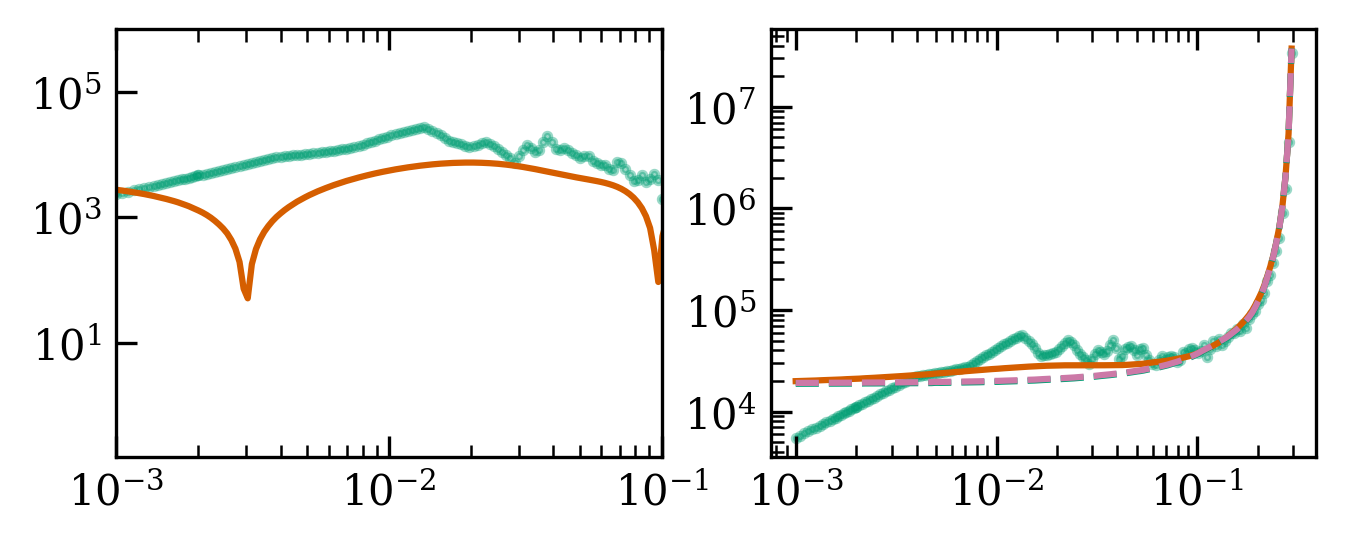

In [463]:
results_sim = {}

path = "/users/odarwish/qeep/results/abacus_recs/"
norm = np.load(path+f"analysis_AbacusSummit_base_c000_ph{simindex:03}_z0.500_{trA}_{trB}_normalization_AB.npy", allow_pickle = True).item()
var = np.load(path+f"analysis_AbacusSummit_base_c000_ph{simindex:03}_z0.500_{trA}_{trB}_variance_AB.npy", allow_pickle = True).item()
shot = np.load(path+f"analysis_AbacusSummit_base_c000_ph{simindex:03}_z0.500_{trA}_{trB}_cross_shot_AB.npy", allow_pickle = True).item()
bis = np.load(path+f"analysis_AbacusSummit_base_c000_ph{simindex:03}_z0.500_{trA}_{trB}_shot_bispectrum_AB.npy", allow_pickle = True).item()
tris = np.load(path+f"analysis_AbacusSummit_base_c000_ph{simindex:03}_z0.500_{trA}_{trB}_shot_trispectrum_AB.npy", allow_pickle = True).item()

Fg_factor = 21/17

#g = lambda out_biases_A, out_biases_B: (out_biases_A['b1']+Fg_factor*1/2*(out_biases_A['b2']*out_biases_B['b1']+out_biases_B['b2']*out_biases_A['b1']))
#g = lambda out_biases_A, out_biases_B: 0.5*(out_biases_A['b1']+Fg_factor*1/2*(get_new_b2(out_biases_A)*out_biases_B['b1']+get_new_b2(out_biases_B)*out_biases_A['b1']))
#s = lambda out_biases_A, out_biases_B: out_biases_A['b1']*out_biases_B['b1']
#t = lambda out_biases_A, out_biases_B:  (out_biases_A['b1']+7/2*1/2*(out_biases_A['bs']*out_biases_B['b1']+out_biases_B['bs']*out_biases_A['b1']))
#biases_rec = {"g": g(out_info_A, out_info_B), "s": s(out_info_A, out_info_B), "t": t(out_info_A, out_info_B)}

g = lambda b1_A, b2_A, b1_B, b2_B: b1_A*b1_B+1/2*21/17*(b1_A*b2_B+b1_B*b2_A) 
s = lambda b1_A, b1_B: b1_A*b1_B
t = lambda b1_A, bs2_A, b1_B, bs2_B:  b1_A*b1_B+1/2*7/2*(b1_A*bs2_B+b1_B*bs2_A) 

biases_rec = {"g": g(out_info_A["b1"], out_info_A["b2"], out_info_B["b1"], out_info_B["b2"]), "s": s(out_info_A["b1"], out_info_B["b1"]), "t": t(out_info_A["b1"], out_info_A["bs"], out_info_B["b1"], out_info_B["bs"])}

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.ticker import LogLocator, LogFormatter, AutoMinorLocator
from matplotlib.gridspec import GridSpec
from matplotlib import patheffects
import matplotlib as mpl


plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "Times New Roman", "DejaVu Serif"],
    "mathtext.fontset": "cm"  # Use Computer Modern math font
})


COLORBLIND_PALETTE = [
    '#0072B2',  # Blue
    '#D55E00',  # Orange
    '#009E73',  # Green
    '#CC79A7',  # Pink
    '#56B4E9',  # Light blue
    '#E69F00',  # Yellow
    '#000000',  # Black
    '#F0E442'   # Light yellow
]

# Use golden ratio for figure dimensions
GOLDEN_RATIO = (5**0.5 - 1) / 2
FIG_WIDTH = 5  # inches
FIG_HEIGHT = 3 * GOLDEN_RATIO
DPI = 300


fig = plt.figure(figsize=(FIG_WIDTH, FIG_HEIGHT), dpi=DPI, facecolor='white')
# Use GridSpec for more control over plot layout
gs = GridSpec(1, 2, figure=fig, left=0.15, right=0.95, bottom=0.15, top=0.92)
ax = fig.add_subplot(gs[0, 0])
ax.tick_params(axis='both', which='major', direction='in', length=5, width=0.8, 
                   top=True, right=False, labelsize=10)
ax.tick_params(axis='both', which='minor', direction='in', length=3, width=0.6, 
               top=True, right=False)

size = ic.size
factor = 1/size

N = norm[(key, key)]**-1.
N = np.nan_to_num(N)

#shot_noise = shot[(key, key)]*N
#plt.loglog(Ks, shot_noise, ls = "--", lw = 2, color = "b")
#shot_noise = bis[(key, key)]*N
#plt.loglog(Ks, shot_noise, ls = ":", lw = 2, color = "b")

cross_sim = p*N*factor
ax.scatter(Ks, abs(cross_sim), color = COLORBLIND_PALETTE[2], alpha = 0.4, s = 3)
results_sim["cross_sim"] = (Ks, cross_sim)


bias = 0
no_rec_bias = 0
kinds = ["s", "t", "g"]
for kk in kinds:
    bias += (N*norm[(key, kk)])*biases_rec[kk]
    no_rec_bias += (N*norm[(key, kk)])

prediction_cross = bias*plinf(Ks)+shot_noise
results_sim["cross_theory"] = (Ks, prediction_cross)
ax.loglog(Ks, abs(prediction_cross), color = COLORBLIND_PALETTE[1])
#ax.loglog(Ks, abs(no_rec_bias*plinf(Ks)+shot_noise), color = COLORBLIND_PALETTE[5], ls = ":")

#ax.loglog(Ks, bias*plinf(Ks), color = COLORBLIND_PALETTE[3])
ax.set_xlim(1e-3, 0.1)
ax.set_ylim(ymax = 1e6)

ax = fig.add_subplot(gs[0, 1])
ax.tick_params(axis='both', which='major', direction='in', length=5, width=0.8, 
                   top=True, right=False, labelsize=10)
ax.tick_params(axis='both', which='minor', direction='in', length=3, width=0.6, 
               top=True, right=False)

N = norm[(key, key)]**-1.
N = np.nan_to_num(N)
shot_noise = tris[(key, key)]*N**2
variance = var[(key, key)]*N**2

prediction_auto = bias**2*plinf(Ks)+variance+shot_noise

auto_sim = pauto*N**2*factor**4
ax.scatter(Ks, auto_sim, color = COLORBLIND_PALETTE[2], alpha = 0.4, s = 3)
results_sim["auto_sim"] = (Ks, auto_sim)

ax.loglog(Ks, prediction_auto, color = COLORBLIND_PALETTE[1])
results_sim["auto_theory"] = (Ks, prediction_auto)
#ax.loglog(Ks, no_rec_bias**2*plinf(Ks)+N+shot_noise, color = COLORBLIND_PALETTE[5], ls = ":")
ax.loglog(Ks, variance+shot_noise, color = COLORBLIND_PALETTE[2], ls = "--")
ax.loglog(Ks, variance, color = COLORBLIND_PALETTE[3], ls = "--")
#ax.set_xlim(1e-3, 0.05)
#ax.set_ylim(ymax = 1e6)

simulations_results[simindex][key] = results_sim

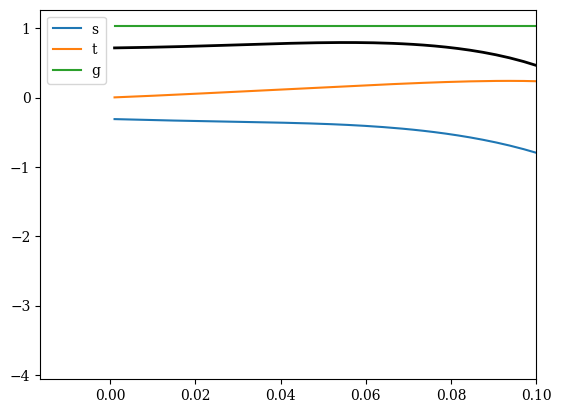

In [464]:
bias = 0
no_rec_bias = 0
kinds = ["s", "t", "g"]
#key = "n"
for kk in kinds:
    bias_temp = (N*norm[(key, kk)])*biases_rec[kk]
    bias += bias_temp
    plt.plot(Ks, bias_temp, label = kk)
plt.plot(Ks, bias, color = "black", lw = 2)
plt.xlim(xmax = 0.1)
plt.legend()

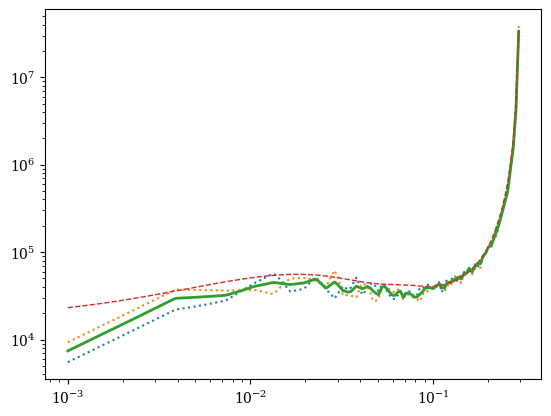

In [239]:
lista = list(range(0, 1+1))
Nsims = len(lista)
auto_mean = 0
auto_mean_sim = 0
cross_mean = 0
for index in lista:
    results = simulations_results[index][key]
    
    Ks, auto_sim = results["auto_sim"]
    auto_mean_sim += auto_sim

    Ks, auto = results["auto_theory"]
    auto_mean += auto
    plt.loglog(Ks, auto_sim, ls = ":")
    

auto_mean_sim /= Nsims
auto_mean /= Nsims

plt.loglog(Ks, auto_mean_sim, lw = 2)
plt.loglog(Ks, auto_mean, lw = 1, ls = "--")